1) Importe as bibliotecas necessárias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import graphviz
from sklearn.metrics import confusion_matrix

2)  Realize a leitura do dataset disponível no SIGAA e apresente os dados lidos.

In [ ]:
dados = pd.read_csv('vendas.csv')
print("Quantidade de colunas: ",dados.shape[1])
dados

Quantidade de colunas:  22


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84543,8409,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,34,,B9,37 QUAIL LANE,...,2,0,2,2400,2575,1998,1,B9,450000,2016-11-28 00:00:00
84544,8410,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,78,,B9,32 PHEASANT LANE,...,2,0,2,2498,2377,1998,1,B9,550000,2017-04-21 00:00:00
84545,8411,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7351,60,,B2,49 PITNEY AVENUE,...,2,0,2,4000,1496,1925,1,B2,460000,2017-07-05 00:00:00
84546,8412,5,WOODROW,22 STORE BUILDINGS,4,7100,28,,K6,2730 ARTHUR KILL ROAD,...,0,7,7,208033,64117,2001,4,K6,11693337,2016-12-21 00:00:00


3) Exclua os seguintes atributos e apresente o dataset resultante:
*   Unnamed: 0
*   NEIGHBORHOOD
*   BUILDING CLASS CATEGORY
*   TAX CLASS AT PRESENT
*   BLOCK
*   LOT
*   EASE-MENT
*   BUILDING CLASS AT PRESENT
*   ADDRESS
*   APARTMENT NUMBER             
*   ZIP CODE
*   GROSS SQUARE FEET
*   BUILDING CLASS AT TIME OF SALE
*   SALE DATE

In [ ]:

dados = dados.drop('Unnamed:  0',axis='columns')
dados = dados.drop('NEIGHBORHOOD',axis='columns')
dados = dados.drop('BUILDING CLASS CATEGORY',axis='columns')
dados = dados.drop('TAX CLASS AT PRESENT',axis='columns')
dados = dados.drop('BLOCK',axis='columns')
dados = dados.drop('LOT',axis='columns')
dados = dados.drop('EASE-MENT',axis='columns')
dados = dados.drop('BUILDING CLASS AT PRESENT',axis='columns')
dados = dados.drop('APARTMENT NUMBER',axis='columns')
dados = dados.drop('ZIP CODE',axis='columns')
dados = dados.drop('GROSS SQUARE FEET',axis='columns')
dados = dados.drop('BUILDING CLASS AT TIME OF SALE',axis='columns')
dados = dados.drop('SALE DATE',axis='columns')


Dataframe criado após a exclusão da coluna faltas
       BOROUGH                 ADDRESS  RESIDENTIAL UNITS  COMMERCIAL UNITS  \
0            1            153 AVENUE B                  5                 0   
1            1   234 EAST 4TH   STREET                 28                 3   
2            1   197 EAST 3RD   STREET                 16                 1   
3            1     154 EAST 7TH STREET                 10                 0   
4            1  301 EAST 10TH   STREET                  6                 0   
...        ...                     ...                ...               ...   
84543        5           37 QUAIL LANE                  2                 0   
84544        5        32 PHEASANT LANE                  2                 0   
84545        5        49 PITNEY AVENUE                  2                 0   
84546        5   2730 ARTHUR KILL ROAD                  0                 7   
84547        5       155 CLAY PIT ROAD                  0                 1   

 

In [ ]:
print("Dataframe criado após a exclusão das colunas")
dados

Dataframe criado após a exclusão das colunas


,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE
0,1,153 AVENUE B,5,0,5,1633,1900,2,6625000
1,1,234 EAST 4TH STREET,28,3,31,4616,1900,2,
2,1,197 EAST 3RD STREET,16,1,17,2212,1900,2,
3,1,154 EAST 7TH STREET,10,0,10,2272,1913,2,3936272
4,1,301 EAST 10TH STREET,6,0,6,2369,1900,2,8000000
...,...,...,...,...,...,...,...,...,...
84543,5,37 QUAIL LANE,2,0,2,2400,1998,1,450000
84544,5,32 PHEASANT LANE,2,0,2,2498,1998,1,550000
84545,5,49 PITNEY AVENUE,2,0,2,4000,1925,1,460000
84546,5,2730 ARTHUR KILL ROAD,0,7,7,208033,2001,4,11693337


4) Calcule a apresente a quantidade de registros em branco para cada atributo.

In [ ]:
dados.describe(include="all")

,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
count,84548.000000,84548,84548.000000,84548.000000,84548.000000,84548,84548.000000,84548.000000,84548
unique,NaN,67563,NaN,NaN,NaN,6062,NaN,NaN,10008
top,NaN,131-05 40TH ROAD,NaN,NaN,NaN,,NaN,NaN,
freq,NaN,210,NaN,NaN,NaN,26252,NaN,NaN,14561
mean,2.998758,NaN,2.025264,0.193559,2.249184,NaN,1789.322976,1.657485,NaN
std,1.289790,NaN,16.721037,8.713183,18.972584,NaN,537.344993,0.819341,NaN
min,1.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,1.000000,NaN
25%,2.000000,NaN,0.000000,0.000000,1.000000,NaN,1920.000000,1.000000,NaN
50%,3.000000,NaN,1.000000,0.000000,1.000000,NaN,1940.000000,2.000000,NaN
75%,4.000000,NaN,2.000000,0.000000,2.000000,NaN,1965.000000,2.000000,NaN


In [ ]:
dados.dtypes

BOROUGH                       int64
ADDRESS                      object
RESIDENTIAL UNITS             int64
COMMERCIAL UNITS              int64
TOTAL UNITS                   int64
SQUARE                       object
YEAR BUILT                    int64
TAX CLASS AT TIME OF SALE     int64
PRICE                        object
dtype: object

In [ ]:
dados[dados==' '] = np.nan
print(dados)

       BOROUGH                 ADDRESS  RESIDENTIAL UNITS  COMMERCIAL UNITS  \
0            1            153 AVENUE B                  5                 0   
3            1     154 EAST 7TH STREET                 10                 0   
4            1  301 EAST 10TH   STREET                  6                 0   
6            1            210 AVENUE B                  8                 0   
9            1     629 EAST 5TH STREET                 24                 0   
...        ...                     ...                ...               ...   
84543        5           37 QUAIL LANE                  2                 0   
84544        5        32 PHEASANT LANE                  2                 0   
84545        5        49 PITNEY AVENUE                  2                 0   
84546        5   2730 ARTHUR KILL ROAD                  0                 7   
84547        5       155 CLAY PIT ROAD                  0                 1   

       TOTAL UNITS  SQUARE  YEAR BUILT  TAX CLASS A

In [ ]:
nulos = pd.isnull(dados).sum()
print(nulos)

BOROUGH                      0
ADDRESS                      0
RESIDENTIAL UNITS            0
COMMERCIAL UNITS             0
TOTAL UNITS                  0
SQUARE                       0
YEAR BUILT                   0
TAX CLASS AT TIME OF SALE    0
PRICE                        0
dtype: int64


5) Apague todos os registros com valores nulos.

In [ ]:
dados.dropna(inplace=True)

6) Apresente a lista com os atributos restantes e os tipos de cada um deles.

In [ ]:
dados.describe(include="all")

,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
count,48799.000000,48799,48799.000000,48799.000000,48799.000000,48799,48799.000000,48799.000000,48799
unique,NaN,42562,NaN,NaN,NaN,5292,NaN,NaN,6325
top,NaN,429 KENT AVENUE,NaN,NaN,NaN,0,NaN,NaN,0
freq,NaN,158,NaN,NaN,NaN,10326,NaN,NaN,10228
mean,3.263079,NaN,2.544273,0.246788,2.809771,NaN,1813.612799,1.480112,NaN
std,0.911316,NaN,17.377548,10.925521,20.642225,NaN,489.815902,0.842273,NaN
min,1.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,1.000000,NaN
25%,3.000000,NaN,1.000000,0.000000,1.000000,NaN,1920.000000,1.000000,NaN
50%,3.000000,NaN,1.000000,0.000000,1.000000,NaN,1930.000000,1.000000,NaN
75%,4.000000,NaN,2.000000,0.000000,2.000000,NaN,1960.000000,2.000000,NaN


In [ ]:
dados.dtypes

BOROUGH                       int64
ADDRESS                      object
RESIDENTIAL UNITS             int64
COMMERCIAL UNITS              int64
TOTAL UNITS                   int64
SQUARE                       object
YEAR BUILT                    int64
TAX CLASS AT TIME OF SALE     int64
PRICE                        object
dtype: object

7) O tipo das colunas SALE PRICE e LAND SQUARE FEET está como object porque existiam valores nulos. Altere os tipos destas colunas para float e apresente novamente as colunas com seus tipos.

In [ ]:
# Os nomes das colunas com espaços em branco foram alterados para simplificar
dados.rename({'SALE PRICE': 'PRICE'}, axis=1, inplace=True)
dados.rename({'LAND SQUARE FEET': 'SQUARE'}, axis=1, inplace=True)
dados.dtypes

BOROUGH                       int64
ADDRESS                      object
RESIDENTIAL UNITS             int64
COMMERCIAL UNITS              int64
TOTAL UNITS                   int64
SQUARE                       object
YEAR BUILT                    int64
TAX CLASS AT TIME OF SALE     int64
PRICE                        object
dtype: object

In [ ]:
dados.PRICE = dados.PRICE.astype(float)
dados.SQUARE = dados.SQUARE.astype(float)

dados.dtypes



BOROUGH                        int64
ADDRESS                       object
RESIDENTIAL UNITS              int64
COMMERCIAL UNITS               int64
TOTAL UNITS                    int64
SQUARE                       float64
YEAR BUILT                     int64
TAX CLASS AT TIME OF SALE      int64
PRICE                        float64
dtype: object

Elimine os outliers dos atributos **LAND SQUARE FEET** e **SALE PRICE**. Considere outlier os valores que estiverem a mais ou a menos de 3 desvios padrões da média.

In [ ]:
df10 = dados.copy()
df10.describe(include='all')

,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
count,48799.000000,48799,48799.000000,48799.000000,48799.000000,4.879900e+04,48799.000000,48799.000000,4.879900e+04
unique,NaN,42562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,429 KENT AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.263079,NaN,2.544273,0.246788,2.809771,3.629395e+03,1813.612799,1.480112,1.172814e+06
std,0.911316,NaN,17.377548,10.925521,20.642225,4.035784e+04,489.815902,0.842273,1.339496e+07
min,1.000000,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000e+00
25%,3.000000,NaN,1.000000,0.000000,1.000000,1.438000e+03,1920.000000,1.000000,8.600000e+04
50%,3.000000,NaN,1.000000,0.000000,1.000000,2.150000e+03,1930.000000,1.000000,4.800000e+05
75%,4.000000,NaN,2.000000,0.000000,2.000000,3.100000e+03,1960.000000,2.000000,8.300000e+05


In [ ]:
limite_inferior = df10['SQUARE'].mean() - 3 * df10['SQUARE'].std()
limite_superior = df10['SQUARE'].mean() + 3 * df10['SQUARE'].std()

print('Limite inferior:',limite_inferior)
print('Limite superior:',limite_superior)


Limite inferior: -117444.13765509715
Limite superior: 124702.92795817714


8) Apresente os outliers do atributo LAND SQUARE FEET.

In [ ]:
print('Dados fora dos limites:')
df10[(df10['SQUARE']<limite_inferior) | (df10['SQUARE']>limite_superior)]

Dados fora dos limites:


,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
5004,1,30 WEST 141ST STREET,771,0,771,189025.0,1959,2,5020000.0
5005,1,15 WEST 139TH STREET,771,0,771,189025.0,1959,2,5020000.0
5006,1,2300 5 AVENUE,771,0,771,189025.0,1959,2,5020000.0
6332,1,460-520 2ND AVENUE,894,8,902,141836.0,1975,2,620000000.0
18805,2,3501 HUTCHINSON AVENUE,0,0,0,181975.0,0,4,11000000.0
...,...,...,...,...,...,...,...,...,...
82567,5,ARTHUR KILL ROAD,0,0,0,328000.0,0,4,4900000.0
82569,5,2911 ARTHUR KILL ROAD,0,0,0,3014056.0,1971,4,7211750.0
83181,5,715 OCEAN TERRACE,0,1,1,2128899.0,1965,4,1.0
83468,5,PAGE AVENUE,0,0,0,319200.0,0,1,250000.0


9) Elimine os outliers do atributo LAND SQUARE FEET

In [ ]:
df10 = df10[(df10['SQUARE']<=limite_superior) & (df10['SQUARE']>=limite_inferior)]

df10.describe(include='all')

,BOROUGH,ADDRESS,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
count,48732.000000,48732,48732.000000,48732.000000,48732.000000,48732.000000,48732.000000,48732.000000,4.873200e+04
unique,NaN,42512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,429 KENT AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.263195,NaN,2.328244,0.220102,2.567081,2773.303599,1814.093450,1.477510,1.137097e+06
std,0.910700,NaN,10.436444,10.536972,14.869255,4662.831653,488.956805,0.839142,1.297441e+07
min,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00
25%,3.000000,NaN,1.000000,0.000000,1.000000,1433.000000,1920.000000,1.000000,8.659150e+04
50%,3.000000,NaN,1.000000,0.000000,1.000000,2150.000000,1930.000000,1.000000,4.800000e+05
75%,4.000000,NaN,2.000000,0.000000,2.000000,3100.000000,1960.000000,2.000000,8.300000e+05


10) Calcule a correlação entre as variáveis numéricas e apresente o mapa de calor.

In [ ]:
corr = df10.corr(numeric_only=True)
corr

,BOROUGH,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,SQUARE,YEAR BUILT,TAX CLASS AT TIME OF SALE,PRICE
BOROUGH,1.000000,-0.099060,-0.009050,-0.076379,0.080759,0.114024,-0.266928,-0.069078
RESIDENTIAL UNITS,-0.099060,1.000000,0.005641,0.705555,0.343078,0.043750,0.025451,0.105545
COMMERCIAL UNITS,-0.009050,0.005641,1.000000,0.712552,0.035828,0.005149,0.047592,0.044920
TOTAL UNITS,-0.076379,0.705555,0.712552,1.000000,0.265389,0.033603,0.055442,0.105819
SQUARE,0.080759,0.343078,0.035828,0.265389,1.000000,0.029034,0.119316,0.192683
YEAR BUILT,0.114024,0.043750,0.005149,0.033603,0.029034,1.000000,-0.227908,0.006342
TAX CLASS AT TIME OF SALE,-0.266928,0.025451,0.047592,0.055442,0.119316,-0.227908,1.000000,0.089648
PRICE,-0.069078,0.105545,0.044920,0.105819,0.192683,0.006342,0.089648,1.000000


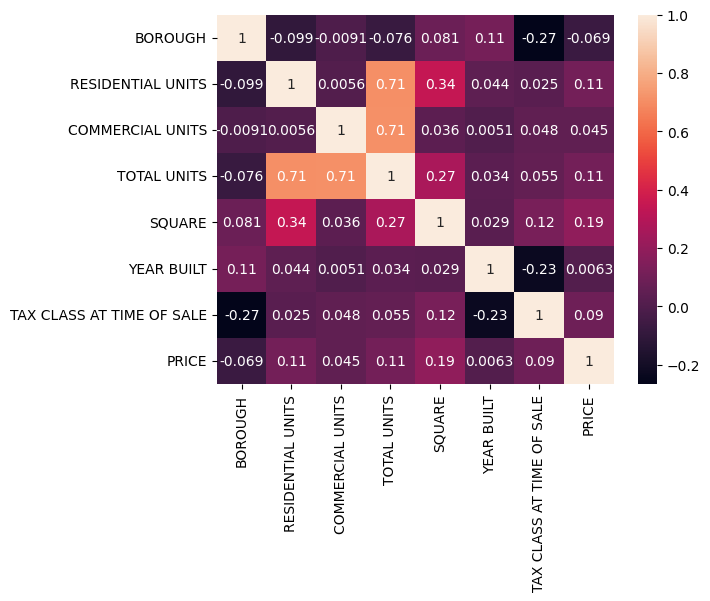

In [ ]:
sns.heatmap(corr,annot=True)
plt.show()

11) Crie um diagrama de dispersão para apresentar a relação entre os atributos LAND SQUARE FEET e SALE PRICE, usando o atributo BOROUGH para atribuir cores diferentes aos pontos. O que pode ser feito para melhorar a interpretação dos dados deste gráfico?

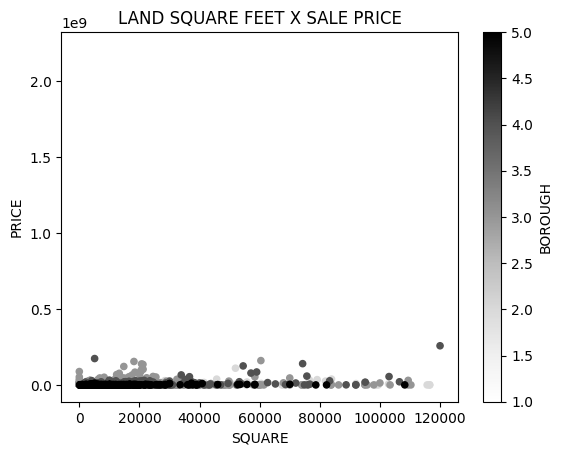

In [ ]:
df10.plot.scatter('SQUARE','PRICE', s = 20, c='BOROUGH', )
plt.title('LAND SQUARE FEET X SALE PRICE')
plt.xlabel('SQUARE')
plt.ylabel('PRICE')
plt.show()


12) Crie um gráfico de colunas para apresentar a média da variável SALE PRICE para cada valor do atributo BOROUGH.

In [ ]:
agrupadoFuncao = df10.groupby(['BOROUGH'])
salarioAgrupadoFuncao = agrupadoFuncao['PRICE'].mean()
salarioAgrupadoFuncao

BOROUGH
1    1.787300e+07
2    5.467325e+05
3    8.164099e+05
4    9.258670e+05
5    5.237007e+05
Name: PRICE, dtype: float64

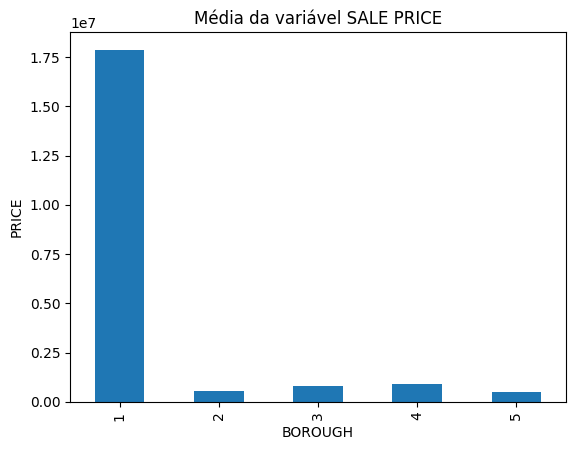

In [ ]:
salarioAgrupadoFuncao.plot.bar('BOROUGH')
plt.title('Média da variável SALE PRICE')
plt.xlabel('BOROUGH')
plt.ylabel('PRICE')
plt.show()

13) Crie um modelo de regressão com todos os atributos. Os dados devem ser divididos da seguinte maneira: 67% para treinamento e 33% para testes. Além disto, use o valor 0 como a semente aleatória deste método.

Apresente os coeficientes da equação e o valor de r2 deste modelo.



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df10['ADDRESS']=le.fit_transform(df10['ADDRESS'])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error

X = df10.drop(['PRICE'] ,axis='columns')
y = df10['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, shuffle=True)
modelo = linear_model.LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
w1 = modelo.coef_
w0 =  modelo.intercept_
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Reta {w1[0]:.3f}x +  {w0:.3f}')
print("Coeficiente de determinação: ", r2)
print("Erro quadrado médio: ",mse)

Reta -746060.038x +  -209191.026
Coeficiente de determinação:  0.03488293914863727
Erro quadrado médio:  321019162252248.7


14) Crie um modelo de regressão com menos atributos (o método para escolha dos atributos fica à escolha do aluno). Os dados devem ser divididos da seguinte maneira: 67% para treinamento e 33% para testes. Além disto, use o valor 0 como a semente aleatória deste método.

Apresente os coeficientes da equação e o valor de r2 deste modelo.


In [ ]:
df4 = df10.copy()
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48732 entries, 0 to 84547
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BOROUGH                    48732 non-null  int64  
 1   ADDRESS                    48732 non-null  int64  
 2   RESIDENTIAL UNITS          48732 non-null  int64  
 3   COMMERCIAL UNITS           48732 non-null  int64  
 4   TOTAL UNITS                48732 non-null  int64  
 5   SQUARE                     48732 non-null  float64
 6   YEAR BUILT                 48732 non-null  int64  
 7   TAX CLASS AT TIME OF SALE  48732 non-null  int64  
 8   PRICE                      48732 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


Criação de uma árvore

In [ ]:
from sklearn.tree import DecisionTreeRegressor

X = df4.drop(['PRICE'] ,axis='columns')
y = df4['PRICE']
modelo = DecisionTreeRegressor(criterion='squared_error', max_depth=7, random_state=42)
modelo.fit(X, y)
print(modelo.feature_names_in_)
print(modelo.feature_importances_)

['BOROUGH' 'ADDRESS' 'RESIDENTIAL UNITS' 'COMMERCIAL UNITS' 'TOTAL UNITS'
 'SQUARE' 'YEAR BUILT' 'TAX CLASS AT TIME OF SALE']
[0.02619702 0.00499935 0.01020068 0.12588715 0.36162154 0.4248654
 0.04473798 0.00149088]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Seleção dos 3 atributos com maior ganho de informação
X_top3 = df4[['SQUARE', 'TOTAL UNITS', 'COMMERCIAL UNITS', 'TAX CLASS AT TIME OF SALE']]
y = df4['PRICE']

# Treinar o modelo
model_top3 = LinearRegression()
model_top3.fit(X_top3, y)

# Previsões e cálculo do R²
y_pred_top3 = model_top3.predict(X_top3)
r2_top3 = r2_score(y, y_pred_top3)
r2 = r2_score(y_test, y_pred)

print(f'Reta {w1[0]:.3f}x +  {w0:.3f}')
print("Coeficiente de determinação: ", r2_top3)
print("R² com os 3 atributos mais importantes:", r2_top3)

Reta -746060.038x +  -209191.026
Coeficiente de determinação:  0.0447204713021816
R² com os 3 atributos mais importantes: 0.0447204713021816


15)Compare os resultados e indique qual dos modelos você escolheria. Justifique sua resposta.

O segundo modelo, em ultimos testes o primeiro modelo perdeu o r2, mas antes estava mais, mas mesmo com um r2 menor, o segundo modelo se torna melhor por ser menos complexoe  usar menos atributos.